In [ ]:
!pip install huggingface_hub -q
from huggingface_hub import HfApi
api = HfApi()
HF_TOKEN = "..."  # add your hf token here
REPO_ID = "Awan8754/wgan-gp"


In [7]:
# importing libs

import os
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt 

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [9]:
"""
Resize  : convert the images from whatever dim to 64x64
ToTensor : convert the PIL to a tensor and convert the 255 to 0-1
Normalize : convert the 0-1 values to -1 ,1 
"""
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [11]:
#importing data from celebA , a subset of 30k images

import os
import random

base_path = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"

all_images = os.listdir(base_path)
random.seed(42)
subset_images = random.sample(all_images, 30000)

print(f"Total images available: {len(all_images)}")
print(f"Subset size: {len(subset_images)}")

Total images available: 202599
Subset size: 30000


In [12]:
# make the custom dataset class

from PIL import Image

class CelebDataset(Dataset):
    def __init__(self, data_path, transform, image_list):
        self.data_path = data_path
        self.transform = transform
        self.images = image_list
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_path,self.images[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform :
            image = self.transform(image)

        return image

In [13]:
base_path = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"

random.seed(42)
subset_images = random.sample(os.listdir(base_path), 30000)

dataset = CelebDataset(
    data_path=base_path,
    transform=transform,
    image_list=subset_images
)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
print(f"total images: {len(dataset)}")
print(f"total batches: {len(dataloader)}")

total images: 30000
total batches: 469


In [14]:
# write the generator

import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, noise_dims =100):
        super().__init__()
        #nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.model = nn.Sequential(
            # 100 -> 512
            nn.ConvTranspose2d(noise_dims, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # 512 -> 256
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 256 -> 128
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 128 -> 64
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # 64 -> 3
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)
        

In [15]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            #3->64
            nn.Conv2d(3,64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            #64->128
            nn.Conv2d(64,128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            #128->256
            nn.Conv2d(128,256,4,2,1,bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            #256->512
            nn.Conv2d(256,512,4,2,1,bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            #512->1
            nn.Conv2d(512,1,4,1,0,bias=False),
            # no sigmoid
        )
        
    def forward(self, x):
        return self.model(x)

In [17]:
# weights initialization 
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    

In [19]:
import torch.optim as optim

netG = Generator(noise_dims=100).to(device)
netC = Critic().to(device)

netG.apply(weights_init)
netC.apply(weights_init)

optimizer_G = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_C = optim.Adam(netC.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [21]:
from torchvision.utils import save_image
num_epochs = 30
fixed_noise = torch.randn(64,100,1,1).to(device)
LAMBDA = 10
for epoch in range(num_epochs):
    for i, real_images in enumerate(dataloader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)
        for _ in range(5):
            netC.zero_grad()
            critic_real = netC(real_images).mean()
            noise = torch.randn(batch_size,100,1,1).to(device)
            fake_images = netG(noise).detach()
            critic_fake = netC(fake_images).mean()
            alpha = torch.rand(batch_size,1,1,1).to(device)
            interpolated = (alpha * real_images + (1 - alpha) * fake_images).requires_grad_(True)
            critic_interpolated = netC(interpolated)
            gradients = torch.autograd.grad(
                outputs=critic_interpolated,
                inputs=interpolated,
                grad_outputs=torch.ones_like(critic_interpolated),
                create_graph=True,
                retain_graph=True
            )[0]
            gradients = gradients.view(batch_size, -1)
            gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
            critic_loss = -(critic_real - critic_fake) + LAMBDA * gradient_penalty
            critic_loss.backward()
            optimizer_C.step()
        netG.zero_grad()
        noise = torch.randn(batch_size,100,1,1).to(device)
        fake_images = netG(noise)
        gen_loss = -torch.mean(netC(fake_images))
        gen_loss.backward()
        optimizer_G.step()
        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch {i}/{len(dataloader)} Loss_C: {critic_loss.item():.4f} Loss_G: {gen_loss.item():.4f}")
    if (epoch+1) % 5 == 0:
        with torch.no_grad():
            fake = netG(fixed_noise)
            save_image(fake, f"/kaggle/working/wgan_epoch_{epoch+1}.png", normalize=True, nrow=8)
            print(f"images saved at epoch {epoch+1}")
    if (epoch+1) % 10 == 0:
        torch.save(netG.state_dict(), "/kaggle/working/netG_latest.pth")
        torch.save(netC.state_dict(), "/kaggle/working/netC_latest.pth")
        api.upload_file(path_or_fileobj="/kaggle/working/netG_latest.pth", path_in_repo="netG_latest.pth", repo_id=REPO_ID, token=HF_TOKEN)
        api.upload_file(path_or_fileobj="/kaggle/working/netC_latest.pth", path_in_repo="netC_latest.pth", repo_id=REPO_ID, token=HF_TOKEN)
        print(f"checkpoint saved to HF at epoch {epoch+1}")

Epoch [1/30] Batch 0/469 Loss_C: 6.5938 Loss_G: 0.1638
Epoch [1/30] Batch 100/469 Loss_C: -28.7905 Loss_G: -0.2374
Epoch [1/30] Batch 200/469 Loss_C: -20.7564 Loss_G: 17.3610
Epoch [1/30] Batch 300/469 Loss_C: -19.2571 Loss_G: -6.6709
Epoch [1/30] Batch 400/469 Loss_C: -17.7702 Loss_G: -0.0198
Epoch [2/30] Batch 0/469 Loss_C: -13.9102 Loss_G: 13.4715
Epoch [2/30] Batch 100/469 Loss_C: -15.3284 Loss_G: 3.3849
Epoch [2/30] Batch 200/469 Loss_C: -13.5277 Loss_G: 31.2318
Epoch [2/30] Batch 300/469 Loss_C: -11.2953 Loss_G: 16.1474
Epoch [2/30] Batch 400/469 Loss_C: -13.0805 Loss_G: -4.1178
Epoch [3/30] Batch 0/469 Loss_C: -12.9164 Loss_G: -17.9066
Epoch [3/30] Batch 100/469 Loss_C: -10.8454 Loss_G: -0.5784
Epoch [3/30] Batch 200/469 Loss_C: -14.1459 Loss_G: 32.4727
Epoch [3/30] Batch 300/469 Loss_C: -11.0873 Loss_G: -2.1813
Epoch [3/30] Batch 400/469 Loss_C: -12.5724 Loss_G: -6.1837
Epoch [4/30] Batch 0/469 Loss_C: -9.9038 Loss_G: 8.1269
Epoch [4/30] Batch 100/469 Loss_C: -10.6065 Loss_G: 1

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

checkpoint saved to HF at epoch 30


netG_latest.pth:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

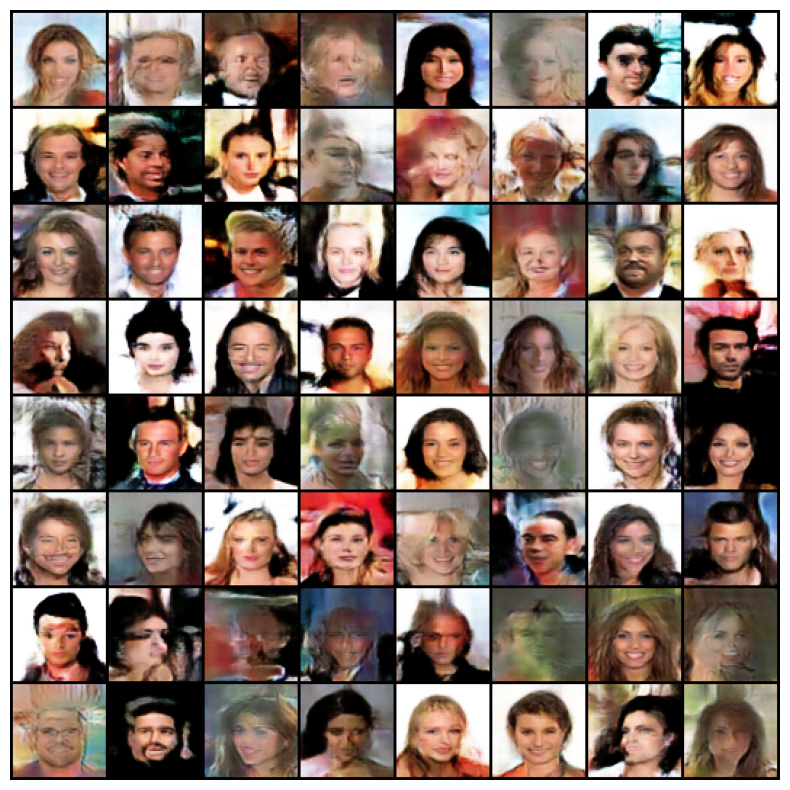

In [22]:
from huggingface_hub import hf_hub_download

# download weights from HF
netG_path = hf_hub_download(repo_id=REPO_ID, filename="netG_latest.pth", token=HF_TOKEN)

# recreate the model and load weights
netG = Generator(noise_dims=100).to(device)
netG.load_state_dict(torch.load(netG_path, map_location=device))
netG.eval()

# generate images
with torch.no_grad():
    fake = netG(fixed_noise)
    save_image(fake, "/kaggle/working/generated.png", normalize=True, nrow=8)

# show the image
from PIL import Image
img = Image.open("/kaggle/working/generated.png")
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()